# Lecture 5: Frameworks

## Setup Libraries

DSPy, LangGraph, and Temporal setup.

In [1]:
import os
from dotenv import load_dotenv
from IPython.display import Image

load_dotenv()
OPENROUTER_API_KEY = os.environ["OPENROUTER_API_KEY"]
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
MODEL = "openai/gpt-5.4-nano"

### DSPy

In [2]:
import dspy

dspy_llm = dspy.LM(f"openrouter/{MODEL}", api_key=OPENROUTER_API_KEY)
dspy.configure(lm=dspy_llm)

### LangGraph

In [3]:
from langchain_openai import ChatOpenAI          # LangGraph uses LangChain's model wrappers
from langgraph.graph import StateGraph, START, END
from langchain_core.globals import set_llm_cache
from llm_cache import SQLiteLLMCache               # small helper in this repo; LangChain core only ships an in-memory cache

langchain_llm = ChatOpenAI(model=MODEL, base_url=OPENROUTER_BASE_URL, api_key=OPENROUTER_API_KEY)
set_llm_cache(SQLiteLLMCache(".langchain_cache.db"))   # like DSPy's cache: identical calls are replayed, not re-billed

### Temporal

In [4]:
import logging
from temporalio import activity, workflow
from temporalio.client import Client
from temporalio.worker import Worker
from temporalio.testing import WorkflowEnvironment

# Starts a local Temporal dev server (downloads the binary on first run; works on macOS/Linux/Windows).
env = await WorkflowEnvironment.start_local(ui=True, ui_port=8233, dev_server_log_level="never")
client = env.client
logging.getLogger("temporalio").setLevel(logging.ERROR)   # hide the SDK's warning tracebacks when an activity attempt fails
print("Temporal UI: http://localhost:8233")

Temporal UI: http://localhost:8233


### tinycal

The calendar app our agents will control. Starts empty every time the notebook runs.

In [5]:
import tinycal

# For lecture, run `uv run python -m tinycal` in a separate terminal first so the calendar
# survives kernel restarts. If nothing is running, this starts one inside the kernel instead.
print("tinycal UI:", tinycal.ensure_server())
print(tinycal.clear_calendar())  # start from an empty calendar
tinycal.add_event("CS329Z Lecture", "2026-10-05", "13:30", "14:50")
tinycal.add_event("CS329Z Lecture", "2026-10-07", "13:30", "14:50")
print(tinycal.today())
print(tinycal.api())  # what the agents will be able to do

tinycal UI: http://127.0.0.1:8765
calendar cleared
2026-10-04 (Sunday)
tinycal SDK  (http://127.0.0.1:8765)

  today()                                                                                      -> str       Get today's date and weekday, e.g. "2026-10-03 (Saturday)".
  list_events(start_date=None, end_date=None)                                                  -> list[dict] List calendar events, sorted by date and start time.
  add_event(title, date, start, end=None, duration_minutes=None, notes='', emoji='')           -> dict      Add an event to the calendar.
  update_event(event_id, title=None, date=None, start=None, end=None, notes=None, emoji=None)  -> dict      Change one or more fields of an existing event. Only the given fields are changed.
  delete_event(event_id)                                                                       -> str       Delete an event by id. Returns a confirmation message.
  find_free_slots(date, duration_minutes=60, day_start='09:00', day_e

# Part 1: DSPy

## Signatures

In [6]:
# The simplest signatures are string signatures

signature = "message -> response"
chat = dspy.Predict(signature)

print(chat(message="Hello, how are you?").response)

Temporal CLI 1.9.1 (Server 1.32.0, UI 2.54.1)

Temporal Server:      localhost:56693
Temporal Persistence: in-memory
Temporal UI:          http://localhost:8233
Temporal Metrics:     http://localhost:56694/metrics
Hello! I’m doing well—thanks for asking. How are you today?


In [7]:
# Signatures are great for structured input and output

sentiment_signature = "message -> sentiment"
sentiment_classifier = dspy.Predict(sentiment_signature)

print(sentiment_classifier(message="I am very happy today!").sentiment)
print(sentiment_classifier(message="I am very angry today!").sentiment)
print(sentiment_classifier(message="I am very confused today!").sentiment)

positive
Negative
negative


In [8]:
# We can apply types
typed_signature = "message: str -> sentiment: " \
   "Literal['positive','negative','neutral'], confidence: float"
typed_sentiment_classifier = dspy.Predict(typed_signature)

print(typed_sentiment_classifier(message="I am very happy today!"))
print(typed_sentiment_classifier(message="I am very angry today!"))
print(typed_sentiment_classifier(message="I am very confused today!"))

Prediction(
    sentiment='positive',
    confidence=0.98
)
Prediction(
    sentiment='negative',
    confidence=0.9
)
Prediction(
    sentiment='negative',
    confidence=0.86
)


In [9]:
dspy_llm.inspect_history(n=3)





[2026-10-04T04:22:53.837132]

System message:

Your input fields are:
1. `message` (str):
Your output fields are:
1. `sentiment` (Literal['positive', 'negative', 'neutral']): 
2. `confidence` (float):
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## message ## ]]
{message}

[[ ## sentiment ## ]]
{sentiment}        # note: the value you produce must exactly match (no extra characters) one of: positive; negative; neutral

[[ ## confidence ## ]]
{confidence}        # note: the value you produce must be a single float value

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Given the fields `message`, produce the fields `sentiment`, `confidence`.


User message:

[[ ## message ## ]]
I am very happy today!

Respond with the corresponding output fields, starting with the field `[[ ## sentiment ## ]]` (must be formatted as a valid Python Literal['positive', 'negative', 'neutral']), then `[[ ## confidence

In [10]:
# When your signature gets more complicated
#     you may want to use a Signature class
import datetime as dt

class ExtractEvent(dspy.Signature):
    """Extract event details from an email."""
    email: str = dspy.InputField()
    event_name: str | None = dspy.OutputField()
    date: dt.date | None = dspy.OutputField()
    start: dt.time | None = dspy.OutputField(desc="24-hour clock")
    duration_minutes: int | None = dspy.OutputField(desc="duration of the event in minutes, if known")

extract = dspy.Predict(ExtractEvent)
extract(email="We have a meeting scheduled for this Friday," \
                                    " October 9th at 10 AM PST.")

Prediction(
    event_name='meeting',
    date=datetime.date(2026, 10, 9),
    start=datetime.time(10, 0),
    duration_minutes=None
)

In [11]:
dspy_llm.inspect_history(n=1)





[2026-10-04T04:22:53.884680]

System message:

Your input fields are:
1. `email` (str):
Your output fields are:
1. `event_name` (UnionType[str, NoneType]): 
2. `date` (UnionType[date, NoneType]): 
3. `start` (UnionType[time, NoneType]): 24-hour clock
4. `duration_minutes` (UnionType[int, NoneType]): duration of the event in minutes, if known
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## email ## ]]
{email}

[[ ## event_name ## ]]
{event_name}        # note: the value you produce must adhere to the JSON schema: {"anyOf": [{"type": "string"}, {"type": "null"}]}

[[ ## date ## ]]
{date}        # note: the value you produce must adhere to the JSON schema: {"anyOf": [{"type": "string", "format": "date"}, {"type": "null"}]}

[[ ## start ## ]]
{start}        # note: the value you produce must adhere to the JSON schema: {"anyOf": [{"type": "string", "format": "time"}, {"type": "null"}]}

[[ ## duration_minutes ## ]]
{duration_minute

## Modules

In [12]:
# Sometimes you may want a different inference
#      strategy than the default "Predict"

extract_cot = dspy.ChainOfThought(ExtractEvent)
extract_cot(email="We have a meeting scheduled for this Friday," \
                                    " October 9th at 10 AM PST.")

Prediction(
    reasoning='The email states there is a meeting “this Friday, October 9th at 10 AM PST.” So the event name is “meeting,” the date is October 9, and the start time is 10:00 AM in PST. No duration is provided.',
    event_name='meeting',
    date=datetime.date(2026, 10, 9),
    start=datetime.time(10, 0),
    duration_minutes=None
)

In [13]:
# A second, tiny LLM call we can compose with the first one

class PickEmoji(dspy.Signature):
    """Pick one emoji that best represents a calendar event."""
    event_name: str = dspy.InputField()
    emoji: str = dspy.OutputField(desc="exactly one emoji character")

pick_emoji = dspy.ChainOfThought(PickEmoji)
pick_emoji(event_name="Dentist")

Prediction(
    reasoning='A dentist appointment is a healthcare-related calendar event, so a dental-themed emoji fits best.',
    emoji='🦷'
)

In [14]:
# Modules are composable and can include python logic

class UpdateCalendarFromEmail(dspy.Module):
    def __init__(self):
        self.extract = dspy.ChainOfThought(ExtractEvent)   # LLM call 1
        self.pick_emoji = dspy.ChainOfThought(PickEmoji)   # LLM call 2

    def forward(self, email: str):
        details = self.extract(email=email)

        # Plain Python control flow: not every email contains an event.
        if details.event_name is None or details.date is None or details.start is None:
            return dspy.Prediction(event=None, status="no event found in email")

        emoji = self.pick_emoji(event_name=details.event_name).emoji
        event = tinycal.add_event(
            title=details.event_name,
            date=details.date,
            start=details.start,
            duration_minutes=details.duration_minutes,  # tinycal assumes 1 hour if None
            emoji=emoji,
        )
        return dspy.Prediction(event=event, status="added to calendar")

In [15]:
update_calendar = UpdateCalendarFromEmail()
print(update_calendar(email="We have a meeting scheduled for this Friday, October 9th at 10 AM PST."))
print(update_calendar(email="Thanks for sending the slides, they look great!"))

Prediction(
    event={'id': 'f25c43aa', 'notes': '', 'emoji': '📅', 'title': 'meeting', 'date': '2026-10-09', 'start': '10:00', 'end': '11:00'},
    status='added to calendar'
)
Prediction(
    event=None,
    status='no event found in email'
)


## Optimizers

Can a **small** model do the extraction task? Let's let DSPy's GEPA optimizer rewrite the prompt for us.

In [16]:
# 1. The data: 50 realistic emails with gold labels (see data/emails.json)
import json, random

rows = json.load(open("data/emails.json"))
print(rows[0]["email"])
print("GOLD:", {k: v for k, v in rows[0].items() if k != "email"})

Dear Prof. Lindqvist,

My thesis committee meeting is scheduled for Wednesday, October 28, 2026 at 2:45pm in Huang 018. It will run for one hour. I'll circulate slides two days before.

Best,
Tomas
GOLD: {'event_name': 'thesis committee meeting', 'date': '2026-10-28', 'start': '14:45', 'duration_minutes': 60}


In [17]:
# Turn them into dspy.Examples. Input: email. Labels: everything else.
examples = [dspy.Example(**row).with_inputs("email") for row in rows]
random.Random(0).shuffle(examples)
trainset, testset = examples[:30], examples[30:]
print(len(trainset), "train /", len(testset), "test")

30 train / 20 test


In [18]:
# 2. The metric: 1 if the date, start time, and duration ALL exactly match the gold label, else 0.
#    (event_name is free-form text, so we don't grade it.)
#    It also returns feedback text: GEPA shows this to the reflection model.
def event_metric(gold, pred, trace=None, pred_name=None, pred_trace=None):
    checks = {
        "date": str(pred.date) == gold.date,
        "start": str(pred.start)[:5] == gold.start,
        "duration_minutes": pred.duration_minutes == gold.duration_minutes,
    }
    score = float(all(checks.values()))
    wrong = [f"{k}: expected {getattr(gold, k)!r}, got {getattr(pred, k)!r}" for k, ok in checks.items() if not ok]
    feedback = "All fields correct." if not wrong else "Wrong -> " + "; ".join(wrong)
    return dspy.Prediction(score=score, feedback=feedback)

evaluate = dspy.Evaluate(devset=testset, metric=event_metric, num_threads=8, display_progress=True)

In [19]:
# Sanity check: our big model (gpt-5.4-nano) should ace this
extract_big = dspy.Predict(ExtractEvent)   # uses dspy_llm (gpt-5.4-nano), the default LM
evaluate(extract_big)

Average Metric: 20.00 / 20 (100.0%): 100%|██████████| 20/20 [00:00<00:00, 33.72it/s] 

2026/10/04 04:22:54 INFO dspy.evaluate.evaluate: Average Metric: 20.0 / 20 (100.0%)


EvaluationResult(score=100.0, results=<list of 20 results>)

In [20]:
# 3. The small model: Gemma 3 12B. 
small_lm = dspy.LM("openrouter/google/gemma-3-12b-it", api_key=OPENROUTER_API_KEY, max_tokens=1024, temperature=0.0)

extract_small = dspy.Predict(ExtractEvent)   # same signature...
extract_small.set_lm(small_lm)               # ...but this predictor uses the small model

# 4. Score the small model BEFORE optimization
before = evaluate(extract_small)

Average Metric: 11.00 / 20 (55.0%): 100%|██████████| 20/20 [00:00<00:00, 255.80it/s]

2026/10/04 04:22:54 INFO dspy.evaluate.evaluate: Average Metric: 11.0 / 20 (55.0%)


In [21]:
# What is the small model actually seeing and saying? Its instructions are just the docstring.
print("INSTRUCTIONS BEFORE:", repr(extract_small.signature.instructions))
small_lm.inspect_history(n=1)

INSTRUCTIONS BEFORE: 'Extract event details from an email.'




[2026-10-04T04:22:54.904864]

System message:

Your input fields are:
1. `email` (str):
Your output fields are:
1. `event_name` (UnionType[str, NoneType]): 
2. `date` (UnionType[date, NoneType]): 
3. `start` (UnionType[time, NoneType]): 24-hour clock
4. `duration_minutes` (UnionType[int, NoneType]): duration of the event in minutes, if known
All interactions will be structured in the following way, with the appropriate values filled in.

Inputs will have the following structure:

[[ ## email ## ]]
{email}

Outputs will be a JSON object with the following fields.

{
  "event_name": "{event_name}        # note: the value you produce must adhere to the JSON schema: {\"anyOf\": [{\"type\": \"string\"}, {\"type\": \"null\"}]}",
  "date": "{date}        # note: the value you produce must adhere to the JSON schema: {\"anyOf\": [{\"type\": \"string\", \"format\": \"date\"}, {\"type\": \"null\"}]}",
  "start": "{start}        # not

In [22]:
# 5. Optimize with GEPA on a small budget (100 metric calls, ~3 minutes).
#    The big model (dspy_llm) reflects on the small model's mistakes; the small model is what gets tuned.
gepa = dspy.GEPA(metric=event_metric, max_metric_calls=100, reflection_lm=dspy_llm, num_threads=8)
extract_optimized = gepa.compile(extract_small, trainset=trainset)

2026/10/04 04:22:54 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 100 metric calls of the program. This amounts to 3.33 full evals on the train set.
2026/10/04 04:22:54 WARNING dspy.teleprompt.gepa.gepa: No valset provided; Using trainset as valset. This is useful as an inference-time scaling strategy where you want GEPA to find the best solutions for the provided tasks in the trainset, as it makes GEPA overfit prompts to the provided trainset. In order to ensure generalization and perform well on unseen tasks, please provide separate trainset and valset. Provide the smallest valset that is just large enough to match the downstream task distribution, while keeping trainset as large as possible.
2026/10/04 04:22:54 INFO dspy.teleprompt.gepa.gepa: Using 30 examples for tracking Pareto scores.
GEPA Optimization:   0%|          | 0/100 [00:00<?, ?rollouts/s]2026/10/04 04:22:55 INFO dspy.evaluate.evaluate: Average Metric: 23.0 / 30 (76.7%)
2026/10/04 04:22:55 INFO dspy.teleprompt.

Average Metric: 2.00 / 3 (66.7%): 100%|██████████| 3/3 [00:00<00:00, 5485.14it/s]

2026/10/04 04:22:55 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Selected program 0 score: 0.7666666666666667
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Proposed new text for self: You are given an email (plain text). Your job is to extract a single calendar event from it and return structured fields.

Input format:
- The input will be one email message as a text block.
- The email may contain:
  - An event title (often a phrase like “Design review …”, “Appointment reminder: …”, “parent-teacher conference …”)
  - A date in common human formats (e.g., “Tue 10/13/2026”, “Nov 10, 2026”, “7 December 2026”)
  - A start time (e.g., “12:30”, “1:15pm”, “6:00 p.m.”), sometimes with timezone like “+00:00” inferred/required
  - A duration (e.g., “15-minute check-in”, “two-hour session”, “about 30 minutes”)
  - Location info (e.g., “meet in room 14”), though output fields may not include it unles


Average Metric: 1.00 / 3 (33.3%): 100%|██████████| 3/3 [00:00<00:00, 246.00it/s]

2026/10/04 04:22:55 INFO dspy.evaluate.evaluate: Average Metric: 1.0 / 3 (33.3%)
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 1: New subsample score 1.0 is not better than old score 2.0, skipping


...

2026/10/04 04:22:55 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 7: Selected program 0 score: 0.7666666666666667
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 7: Proposed new text for self: You are given a single email (plain text). Your job is to extract calendar event details from it and return them in a structured JSON-like set of fields.

Input/format:
- Input is an email body that may contain a date, start time, duration, and a short description of the activity.
- Dates are written in common human formats such as: M/D/YYYY, DD Month YYYY, or “Monday, December 7, 2026”.
- Times are written like “10:45am”, “1:15 PM”, or “09:30”.
- Durations may be explicitly stated as “two-hour session”, “15-minute check-in”, “It’s a quick 15-minute check-in”, etc.
- The email may include a location or additional notes, but you only need to extract the fields described below.

Output fields (use these keys 


Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:00<00:00, 159.45it/s]

2026/10/04 04:22:55 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)



Average Metric: 30.00 / 30 (100.0%): 100%|██████████| 30/30 [00:00<00:00, 158.70it/s]

2026/10/04 04:22:55 INFO dspy.evaluate.evaluate: Average Metric: 30.0 / 30 (100.0%)
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 7: Accepted candidate (subsample score 2.0 -> 3.0); running full eval.
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 7: Found a better program on the valset with score 1.0.
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 7: Valset score for new program: 1.0 (coverage 30 / 30)
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 7: Val aggregate for new program: 1.0
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 7: Individual valset scores for new program: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0, 12: 1.0, 13: 1.0, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0, 19: 1.0, 20: 1.0, 21: 1.0, 22: 1.0, 23: 1.0, 24: 1.0, 25: 1.0, 26: 1.0, 27: 1.0, 28: 1.0, 29: 1.0}
2026/10/04 04:22:55 INFO dspy.teleprompt.gepa.gepa: Iteration 7: New valset par

In [23]:
# 6. Score the small model AFTER optimization
after = evaluate(extract_optimized)
print(f"small model before: {before.score:.1f}%   after: {after.score:.1f}%")

Average Metric: 20.00 / 20 (100.0%): 100%|██████████| 20/20 [00:00<00:00, 227.11it/s]

2026/10/04 04:22:55 INFO dspy.evaluate.evaluate: Average Metric: 20.0 / 20 (100.0%)



small model before: 55.0%   after: 100.0%


In [24]:
# The only thing GEPA changed is the instructions text:
print(extract_optimized.signature.instructions)

You are given a single email (plain text). Your job is to extract calendar event details from it and return them in a structured JSON-like set of fields.

Input/format:
- Input is an email body that may contain a date, start time, duration, and a short description of the activity.
- Dates are written in common human formats such as: M/D/YYYY, DD Month YYYY, or “Monday, December 7, 2026”.
- Times are written like “10:45am”, “1:15 PM”, or “09:30”.
- Durations may be explicitly stated as “two-hour session”, “15-minute check-in”, “It’s a quick 15-minute check-in”, etc.
- The email may include a location or additional notes, but you only need to extract the fields described below.

Output fields (use these keys exactly):
- event_name: short title of the event/activity (e.g., “Home inspection”, “Soccer practice”, “Moving”).
- date: the event date in ISO format YYYY-MM-DD.
- start: the start time in HH:MM:SS format, and when the source examples imply timezone offsets, include the offset; othe

## Agents

In [25]:
# An agent in one line.  Specify the inputs/outputs and the tools it can use.
agent = dspy.ReAct("request -> summary", tools=tinycal.TOOLS)

result = agent(request="Schedule a 30-minute coffee with John on Oct 7, 2026 in the afternoon after my lectures, "
                       "and put a book emoji on every one of my lectures for that same week.")
print(result.summary)

- Added 📚 to lectures on:
  - 2026-10-05 (13:30–14:50) — CS329Z Lecture
  - 2026-10-07 (13:30–14:50) — CS329Z Lecture
- Scheduled:
  - “Coffee with John” on 2026-10-07 from 15:00–15:30


In [26]:
# RLMs can handle really long context
rows = json.load(open("data/emails.json"))
inbox = "\n\n=====\n\n".join(row["email"] for row in rows)

rlm = dspy.RLM("inbox, question -> event_names: list[str], dates: list[str]", max_iters=8)
result = rlm(inbox=inbox, question="Which events are held in the Gates building, and on what dates?")
print(result.event_names)
print(result.dates)

['The thesis defense for Wei Zhang']
['Monday, December 7, 2026']


# Part 2: LangGraph

## Defining a Graph

In [27]:
# Structured Output is Possible in LangGraph too.

from pydantic import BaseModel, Field

class EventDetails(BaseModel):
    """Extract event details from an email."""
    event_name: str | None = Field(description="short title for the event, e.g. 'Dentist' or 'Meeting'. Always set when the email mentions an event")
    date: dt.date | None
    start: dt.time | None = Field(description="24-hour clock")
    duration_minutes: int | None = Field(description="duration of the event in minutes, if known")

extract_llm = langchain_llm.with_structured_output(EventDetails)

In [28]:
# First we define the state
from typing import TypedDict

class State(TypedDict):
    email: str
    details: EventDetails | None

In [29]:
# Next: a node that reads the state, performs some computation,
#       and returns the part you changed
def extract_node(state: State):                       
    return {"details": extract_llm.invoke(state["email"])}

In [30]:
from langgraph.graph import StateGraph, START, END

# Build the Graph
builder = StateGraph(State)
builder.add_node("extract", extract_node)
builder.add_edge(START, "extract")
builder.add_edge("extract", END)
graph = builder.compile()

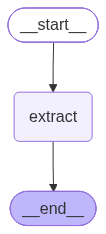

In [31]:
# Visualize the graph
Image(graph.get_graph().draw_mermaid_png())

In [32]:
# Invoke the graph 
graph.invoke({"email": "We have a meeting scheduled for this Friday, October 9th at 10 AM PST."})

{'email': 'We have a meeting scheduled for this Friday, October 9th at 10 AM PST.',
 'details': EventDetails(event_name='Meeting', date=datetime.date(2026, 10, 9), start=datetime.time(10, 0, tzinfo=TzInfo(-25200)), duration_minutes=None)}

## Conditional Edges (Enable Workflows)

In [33]:
# Define the State
class CalendarState(State):
    emoji: str
    status: str

In [34]:
# Create Nodes
def pick_emoji_node(state: CalendarState):
    reply = langchain_llm.invoke(f"Reply with exactly one emoji character, nothing else, for a calendar event called '{state['details'].event_name}'.")
    return {"emoji": reply.text.strip()}

def add_to_calendar_node(state: CalendarState):
    d = state["details"]
    tinycal.add_event(d.event_name, d.date, d.start, duration_minutes=d.duration_minutes, emoji=state["emoji"])
    return {"status": "added to calendar"}

In [35]:
# Create a Conditional Edge
from typing import Literal

def route(state: CalendarState) -> Literal["pick_emoji", "__end__"]:   # plain Python decides where to go next
    d = state["details"]
    return "pick_emoji" if d.event_name and d.date and d.start else END

In [36]:
# Build the graph
builder = StateGraph(CalendarState)
builder.add_node("extract", extract_node)
builder.add_node("pick_emoji", pick_emoji_node)
builder.add_node("add_to_calendar", add_to_calendar_node)

builder.add_edge(START, "extract")
builder.add_conditional_edges("extract", route)        # dotted arrows in the drawing
builder.add_edge("pick_emoji", "add_to_calendar")
builder.add_edge("add_to_calendar", END)

calendar_graph = builder.compile()

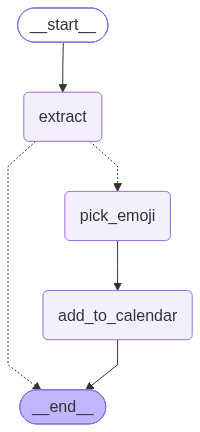

In [37]:
Image(calendar_graph.get_graph().draw_mermaid_png())

In [38]:
calendar_graph.invoke({"email":"Dentist Appointment Confirmed, Wedndesday October 7th at 11am."})

{'email': 'Dentist Appointment Confirmed, Wedndesday October 7th at 11am.',
 'details': EventDetails(event_name='Dentist Appointment', date=datetime.date(2026, 10, 7), start=datetime.time(11, 0, tzinfo=TzInfo(0)), duration_minutes=None),
 'emoji': '🦷',
 'status': 'added to calendar'}

In [39]:
calendar_graph.invoke({"email":"CS329Z Open Router Credits have arrived!  Please check your inbox."})

{'email': 'CS329Z Open Router Credits have arrived!  Please check your inbox.',
 'details': EventDetails(event_name='Open Router Credits Arrival', date=None, start=None, duration_minutes=None)}

## Agents

In [40]:
# Similar to DSPy we can make an agent in two lines
from langchain.agents import create_agent
langchain_cal_agent = create_agent(langchain_llm, tools=tinycal.TOOLS)

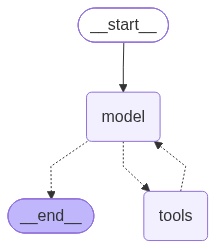

In [41]:
Image(langchain_cal_agent.get_graph().draw_mermaid_png())

In [42]:
langchain_cal_agent.invoke({"messages": [("user", "Please move my coffee with John on Oct 7th to be 30 minutes later")]})

{'messages': [HumanMessage(content='Please move my coffee with John on Oct 7th to be 30 minutes later', additional_kwargs={}, response_metadata={}, id='2117ed53-9d09-4e8b-a4d5-9c9519ca0550'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 710, 'total_tokens': 744, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0.0001845, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0.0001845, 'upstream_inference_prompt_cost': 0.000142, 'upstream_inference_completions_cost': 4.25e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-5.4-nano', 'system_fingerprint': None, 'id': 'gen-1791104067-tEqGStCR3WsIPHpQixP3', 'service_tier': 'default', 'finish_reason': '

# Part 3: Temporal

## Making a Durable Workflow

In [43]:
# Activities are functional units that can fail
#       They are orchestrated by the workflow
#       Here we reuse our DSPy extraction and emoji selection modules
emoji_cot = dspy.ChainOfThought(PickEmoji)
@activity.defn
def extract_event(email: str) -> dict | None:
    d = extract_cot(email=email)
    if d.event_name is None or d.date is None or d.start is None:
        return None
    return {"title": d.event_name, 
            "date": str(d.date), 
            "start": str(d.start)[:5], 
            "duration_minutes": d.duration_minutes}

@activity.defn
def select_emoji(title: str) -> str:
    return emoji_cot(event_name=title).emoji

@activity.defn
def add_to_calendar(details: dict, emoji: str) -> str:
    tinycal.add_event(**details, emoji=emoji)
    return "added to calendar"

In [44]:
# The workflow: UpdateCalendarFromEmail.forward, with execute_activity around every call that can fail.
# It must be deterministic (no LLM calls, no I/O of its own), because Temporal re-runs it from the record.
from datetime import timedelta
from temporalio.common import RetryPolicy

RETRY = RetryPolicy(initial_interval=timedelta(seconds=1), maximum_attempts=5)

@workflow.defn(sandboxed=False)              
class CalendarWorkflow:
    @workflow.run
    async def run(self, email: str) -> str:
        details = await workflow.execute_activity(extract_event, email, 
                                                start_to_close_timeout=timedelta(minutes=1), retry_policy=RETRY)
        if details is None:
            return "no event found in email"
        emoji = await workflow.execute_activity(select_emoji, details["title"], 
                                                start_to_close_timeout=timedelta(minutes=1), retry_policy=RETRY)
        return await workflow.execute_activity(add_to_calendar, args=[details, emoji], 
                                               start_to_close_timeout=timedelta(minutes=1), retry_policy=RETRY)

In [45]:
# A worker is the process that actually runs workflows and activities.
import asyncio
from concurrent.futures import ThreadPoolExecutor

worker = Worker(client, task_queue="calendar", 
                workflows=[CalendarWorkflow], 
                activities=[extract_event, select_emoji, add_to_calendar],
                activity_executor=ThreadPoolExecutor(4))
worker_task = asyncio.create_task(worker.run())

In [46]:
# Run it. Every step is recorded: open http://localhost:8233 and click on calendar-1.
print(await client.execute_workflow(CalendarWorkflow.run, 
                                    "Office hours are Thursday October 8th at 3pm",
                                    id="calendar-1", 
                                    task_queue="calendar")
                                )
print(await client.execute_workflow(CalendarWorkflow.run,
                                    "Thanks for sending the slides, they look great!",
                                    id="calendar-2",
                                    task_queue="calendar")
                                )

added to calendar
no event found in email


## Retry Flaky Activities

In [47]:
# This activity simulates a flaky service that fails twice before succeeding.

@activity.defn(name="select_emoji") # activities are matched by name
def flaky_select_emoji(title: str) -> str:
    print("select_emoji attempt", activity.info().attempt)
    if activity.info().attempt < 3:
        raise RuntimeError("503 Service Unavailable")
    return emoji_cot(event_name=title).emoji

In [48]:
# Activities fail: rate limits, timeouts, flaky networks. 
#       The server retries the activity for you, according to the `RetryPolicy`.

worker = Worker(client, task_queue="retries", 
                workflows=[CalendarWorkflow], 
                activities=[extract_event, flaky_select_emoji, add_to_calendar],
                activity_executor=ThreadPoolExecutor(4))
retry_worker_task = asyncio.create_task(worker.run())

await client.execute_workflow(CalendarWorkflow.run,
                               "Go for a walk on Tuesday, October 6, 2026 at 9am," \
                               " should take 30 minutes.", id="retry-1", task_queue="retries")

select_emoji attempt 1
select_emoji attempt 2
select_emoji attempt 3


'added to calendar'

## Server-based timing

In [49]:
# Add the event now, then sleep until it's time for a reminder. 
#       A workflow can sleep for a months or even years in one line.
@workflow.defn(sandboxed=False)
class ReminderWorkflow:
    @workflow.run
    async def run(self, email: str, seconds: int) -> str:
        status = await workflow.execute_child_workflow(CalendarWorkflow.run,
                                email, id="reminder-1-calendar")
        await workflow.sleep(seconds)
        return f"Reminder! ({email})"

worker = Worker(client, task_queue="reminders", 
                workflows=[ReminderWorkflow, CalendarWorkflow], 
                activities=[extract_event, select_emoji, add_to_calendar],
                activity_executor=ThreadPoolExecutor(4))
reminder_worker_task = asyncio.create_task(worker.run())

In [50]:
# Start it, let the calendar steps finish, then kill the worker in the middle of the sleep.
handle = await client.start_workflow(ReminderWorkflow.run, 
                    args=["Lab meeting on Thursday, October 8th, 2026 at 11am for 60 minutes.", 20],
                    id="reminder-1", 
                    task_queue="reminders"
               )
await asyncio.sleep(10)
reminder_worker_task.cancel()
print("workflow status:", (await handle.describe()).status.name)      # still RUNNING, with no worker alive

workflow status: RUNNING


In [51]:
# Bring a worker back. The timer fires and the workflow finishes. 
#       The LLM steps are not re-run: their results were already recorded.
worker = Worker(client, task_queue="reminders", 
                workflows=[ReminderWorkflow, CalendarWorkflow], 
                activities=[extract_event, select_emoji, add_to_calendar],
                activity_executor=ThreadPoolExecutor(4)
            )
reminder_worker_task = asyncio.create_task(worker.run())

print(await handle.result())
print([e["title"] for e in tinycal.list_events("2026-10-08")])       # one Lab meeting, not two

Reminder! (Lab meeting on Thursday, October 8th, 2026 at 11am for 60 minutes.)
['Lab meeting', 'Office hours']
